# **03장. 선형 회귀 모델**

[실습 03-01]

In [ ]:
!pip install koreanize_matplotlib
import koreanize_matplotlib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 29.6 MB/s eta 0:00:00


[실습 03-02]

In [ ]:
df=pd.read_csv("베이스볼.csv", encoding='cp949')
df

,max_speed,fourball,strikeout,era
0,158,5,7,3.37
1,149,5,4,3.01
2,153,7,0,3.83
3,136,5,6,3.44
4,140,7,4,4.16
...,...,...,...,...
95,144,5,7,2.71
96,151,5,3,3.64
97,164,4,3,3.73
98,148,7,2,3.98


[실습 03-03]

In [ ]:
df.describe()

,max_speed,fourball,strikeout,era
count,100.00000,100.000000,100.000000,100.000000
mean,150.30000,3.700000,4.840000,3.078000
std,8.88251,2.388948,3.073905,0.707328
min,135.00000,0.000000,0.000000,1.670000
25%,144.00000,2.000000,2.000000,2.515000
50%,152.00000,4.000000,5.000000,3.055000
75%,157.00000,6.000000,8.000000,3.577500
max,165.00000,7.000000,10.000000,5.010000


[실습 03-04]

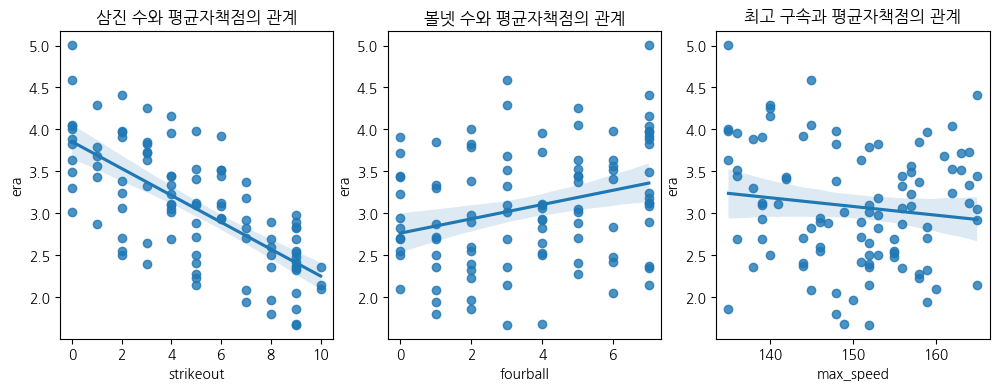

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1,3,1)
sns.regplot(x='strikeout', y='era', data=df)
plt.title("삼진 수와 평균자책점의 관계")

plt.subplot(1,3,2)
sns.regplot(x='fourball', y='era', data=df)
plt.title("볼넷 수와 평균자책점의 관계")

plt.subplot(1,3,3)
sns.regplot(x='max_speed', y='era', data=df)
plt.title("최고 구속과 평균자책점의 관계")
plt.show()

[실습 03-05]

In [ ]:
y=df['era']           # 타깃
X=df[['strikeout']]   # 입력,이중 브래킷 주의(2차원 리스트)
X.head(5)             # 처음 5개만 출력

,strikeout
0,7
1,4
2,0
3,6
4,4


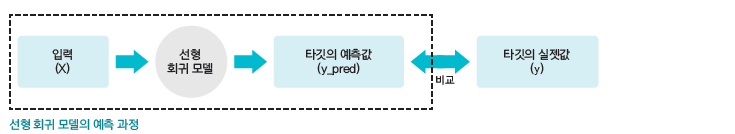

[실습 03-06]

In [ ]:
w=-0.5; b=5
df['pred_era']=w*X+b
df['error']=df['era']-df['pred_era']
df

,max_speed,fourball,strikeout,era,pred_era,error
0,158,5,7,3.37,1.5,1.87
1,149,5,4,3.01,3.0,0.01
2,153,7,0,3.83,5.0,-1.17
3,136,5,6,3.44,2.0,1.44
4,140,7,4,4.16,3.0,1.16
...,...,...,...,...,...,...
95,144,5,7,2.71,1.5,1.21
96,151,5,3,3.64,3.5,0.14
97,164,4,3,3.73,3.5,0.23
98,148,7,2,3.98,4.0,-0.02


[실습 03-07]

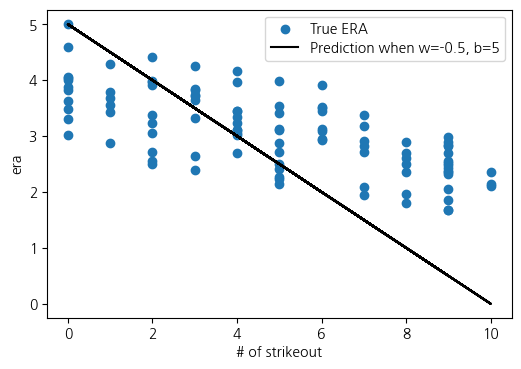

In [ ]:
plt.figure(figsize=(6, 4))
plt.scatter(df["strikeout"], df["era"], label="True ERA")
plt.plot(df["strikeout"], df["pred_era"],"k-", label=f'Prediction when w={w}, b={b}')
plt.xlabel("# of strikeout")
plt.ylabel("era")
plt.legend()
plt.show()

[실습 03-08]

In [ ]:
MSE=np.mean(df['error']**2)
print('평균제곱오차=', np.round(MSE,3))

평균제곱오차= 1.582


📌평균제곱오차를 계산하는 함수 만들기

In [ ]:
def mse(true, pred):           # 함수 정의
  q=np.mean((true-pred)**2)    # 규칙 연산
  return q                     # 결과 반환

z=mse(y,df['pred_era']) # 함수 호출: 타깃의 참값과 예측값을 입력
print(f"mse 함수로 계산한 평균제곱오차={z: .3f}")  # f-스트링 기법으로 MSE 출력

mse 함수로 계산한 평균제곱오차= 1.582


[실습 03-09]

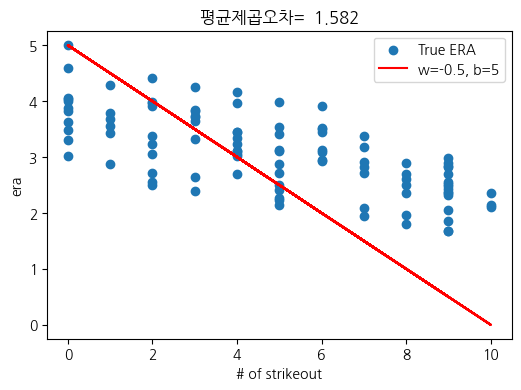

In [ ]:
plt.figure(figsize=(6, 4))

MSE=np.mean(df['error']**2)  # 또는 mse 함수 사용 가능

plt.scatter(df["strikeout"], df["era"], label="True ERA")
plt.plot(df["strikeout"], df["pred_era"],"r", label=f'w={w}, b={b}')
plt.xlabel("# of strikeout")
plt.ylabel("era")
plt.legend()
plt.title(f"평균제곱오차= {MSE: .3f}") # f_string (문자와 변수 결합)
plt.show()

📌 파라미터 변경해서 반복해 보기

In [ ]:
w=-0.3; b=5
df['pred_era']=w*X+b
df['error']=df['era']-df['pred_era']
df

,max_speed,fourball,strikeout,era,pred_era,error
0,158,5,7,3.37,2.9,0.47
1,149,5,4,3.01,3.8,-0.79
2,153,7,0,3.83,5.0,-1.17
3,136,5,6,3.44,3.2,0.24
4,140,7,4,4.16,3.8,0.36
...,...,...,...,...,...,...
95,144,5,7,2.71,2.9,-0.19
96,151,5,3,3.64,4.1,-0.46
97,164,4,3,3.73,4.1,-0.37
98,148,7,2,3.98,4.4,-0.42


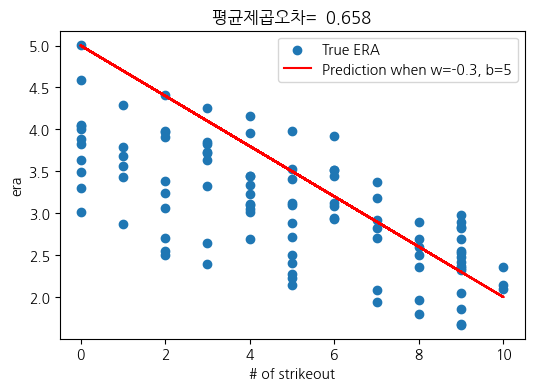

In [ ]:
plt.figure(figsize=(6, 4))

MSE=np.mean(df['error']**2)

plt.scatter(df["strikeout"], df["era"], label="True ERA")
plt.plot(df["strikeout"], df["pred_era"],"r", label=f'Prediction when w={w}, b={b}')
plt.xlabel("# of strikeout")
plt.ylabel("era")
plt.legend()
plt.title(f"평균제곱오차= {MSE: .3f}") # f_string (문자와 변수 결합)
plt.show()

📌 책에 있는 MSE 변화 그림 만들기


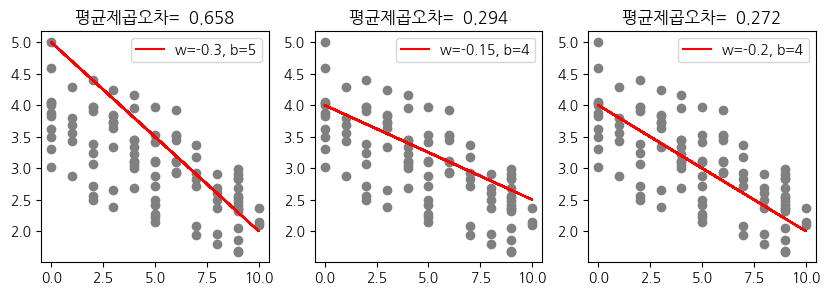

In [ ]:
plt.figure(figsize=(10,3))

plt.subplot(1,3,1)
w=-0.3; b=5
df['pred_era']=w*X+b; df['error']=df['era']-df['pred_era'] ; MSE=np.mean(df['error']**2)
plt.scatter(df["strikeout"], df["era"], color='gray')
plt.plot(df["strikeout"], df["pred_era"],"r", label=f'w={w}, b={b}')
plt.title(f"평균제곱오차= {MSE: .3f}")
plt.legend()

plt.subplot(1,3,2)
w=-0.15; b=4
df['pred_era']=w*X+b; df['error']=df['era']-df['pred_era'] ; MSE=np.mean(df['error']**2)

plt.scatter(df["strikeout"], df["era"], color='gray')
plt.plot(df["strikeout"], df["pred_era"],"r", label=f'w={w}, b={b}')
plt.title(f"평균제곱오차= {MSE: .3f}")
plt.legend()

plt.subplot(1,3,3)
w=-0.2; b=4
df['pred_era']=w*X+b; df['error']=df['era']-df['pred_era'] ; MSE=np.mean(df['error']**2)

plt.scatter(df["strikeout"], df["era"], color='gray')
plt.plot(df["strikeout"], df["pred_era"],"r", label=f'w={w}, b={b}')
plt.title(f"평균제곱오차= {MSE: .3f}")
plt.legend()
plt.show()

[실습 03-10]

In [ ]:
# 타깃과 입력 지정
y=df['era']
X=df[['strikeout']]  # 피쳐 1개

from sklearn.linear_model import LinearRegression

# 모델 설정
model=LinearRegression()

# 모델 학습
model.fit(X, y)

model  # 출력??

LinearRegression()

학습된 모델 객체를 바로 출력하여 학습 결과를 확인할 수는 없습니다.
* 객체가 어떤 클래스에 의해 생성되었는지만 보여줍니다.
* 결과를 볼려면 이 객체에 생성된 메서드를 사용해야 합니다.

[실습 03-11]

In [ ]:
print("가중치(weights)=", model.coef_)  # 객체 속성
print("편향(bias)=", model.intercept_)

가중치(weights)= [-0.1603438]
편향(bias)= 3.8540639698965196


[실습 03-12]

In [ ]:
y_pred=model.predict(X) # 피쳐 X를 입력하여 모델의 예측값 계산
print(y_pred[:10])

[2.7316574  3.21268879 3.85406397 2.8920012  3.21268879 3.85406397
 3.69372017 3.85406397 3.85406397 3.05234499]


[실습 03-13]

In [ ]:
mean_squared_error(y, y_pred) # MSE를 구해주는 함수

0.2548071343538869

[실습 03-14]

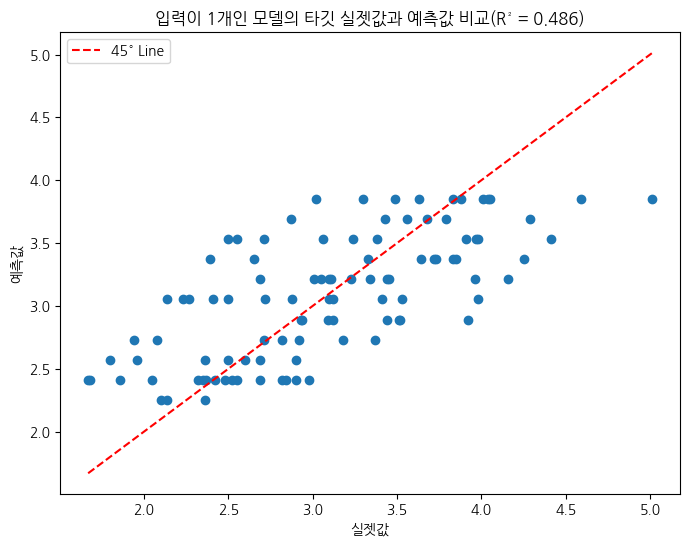

In [ ]:
y_pred=model.predict(X)

from sklearn.metrics import r2_score
acc = r2_score(y, y_pred)  # R²예측력 계산

# 예측값과 실제값 비교 그림 (45도 일치선 방법)
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', label='45° Line')

plt.title(f'입력이 1개인 모델의 타깃 실젯값과 예측값 비교(R² = {acc:.3f})')
plt.xlabel('실젯값')
plt.ylabel('예측값')
plt.legend()
plt.show()

[실습 03-15]

In [ ]:
y=df['era']
X=df[['strikeout', 'fourball', 'max_speed']]  # 피쳐 3개

from sklearn.linear_model import LinearRegression
model2=LinearRegression()
model2.fit(X, y)

print("가중치(weights)=", model2.coef_)
print("편향 (bias)=", model2.intercept_); print()

y_pred=model2.predict(X) # 피쳐 X를 입력하여 모형의 예측값 계산
MSE=mean_squared_error(y, y_pred)
print("평균제곱오차=", MSE)

가중치(weights)= [-0.15720595  0.07475011 -0.00907497]
편향 (bias)= 4.926268916009339

평균제곱오차= 0.21609621157270492


📌 개선된 모델의 예측 정확도 시각화하기

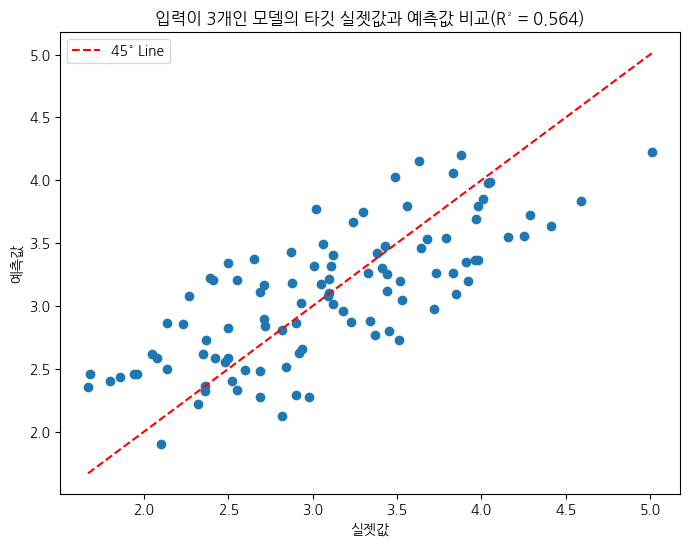

In [ ]:
y_pred=model2.predict(X)  # 설정된 모델의 이름을 정확히 확인!!
from sklearn.metrics import mean_squared_error, r2_score
acc = r2_score(y, y_pred)  # R²정확도 지표 계산

# 예측값과 실제값 비교 그림 (45도 기준선 방법)
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', label='45° Line')

plt.title(f'입력이 3개인 모델의 타깃 실젯값과 예측값 비교(R² = {acc:.3f})')
plt.xlabel('실젯값'); plt.ylabel('예측값')
plt.legend(); plt.show()

[실습 03-16]

In [ ]:
import warnings
warnings.filterwarnings('ignore')

X_new=[[10, 0, 160]]  # 특성 3개 (삼진, 볼넷, 최고 구속)
print(f"이 투수의 평균자책점은 {model2.predict(X_new)}로 예측됩니다.")

이 투수의 평균자책점은 [1.90221471]로 예측됩니다.


In [ ]:
X_new=[[11, 0, 160]]  # 특성 3개 (삼진, 볼넷, 최고구속)
print(f"이 투수의 평균자책점 {model2.predict(X_new)}로 예측됩니다.")

이 투수의 평균자책점 [1.74500876]로 예측됩니다.


#### **복습: 선형 회귀모델 가중치의 의미를 정확하게 이해합시다**
- 다른 모든 입력 변수가 동일할때, 한 입력 변수가 1만큼 증가할때 타깃의 변화 예측

In [ ]:
print(f"가중치={model2.coef_}")
print("------------------------------------------------------------------------------------------------------------")
for k in range(X.shape[1]):
  print(f"다른 피처가 같을 때, {X.columns[k]}이 1만큼 증가하면 타깃의 예측값은 {model2.coef_[k]}만큼 증가합니다.")
  print()

가중치=[-0.15720595  0.07475011 -0.00907497]
------------------------------------------------------------------------------------------------------------
다른 피처가 같을 때, strikeout이 1만큼 증가하면 타깃의 예측값은 -0.15720595393096135만큼 증가합니다.

다른 피처가 같을 때, fourball이 1만큼 증가하면 타깃의 예측값은 0.07475010578710417만큼 증가합니다.

다른 피처가 같을 때, max_speed이 1만큼 증가하면 타깃의 예측값은 -0.009074966669299876만큼 증가합니다.

